# Тематическое моделирование фильмов (ТОП-250 Кинопоиска)


In [1]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pymorphy3
from wordcloud import WordCloud, STOPWORDS
import gensim
from gensim.models import CoherenceModel

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

plt.rcParams["figure.figsize"] = (14, 6)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\000\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Загрузка объединенного датасета фильмов


In [2]:
df = pd.read_csv("merged_films.csv")
print("Films dataset:", df.shape)
display(df.head())


Films dataset: (254, 6)


,name,country,category,year,rating,description
0,1+1,Франция,драма,2011,8.859,"Пострадав в результате несчастного случая, бог..."
1,12 лет рабства,Великобритания,драма,2013,7.948,США до Гражданской войны. Семьянин Соломон Нор...
2,12 разгневанных мужчин,США,драма,1956,8.530,"Юношу обвиняют в убийстве собственного отца, е..."
3,12 стульев,СССР,комедия,1971,8.305,Во время революции и последовавшего за ней кра...
4,F1,США,драма,2025,8.175,В 1990-х Сонни Хейс был восходящей звездой «Фо...


## Краткий обзор датасета


In [3]:
print("Года выпуска:")
print(df["year"].value_counts().sort_index().head(10), "\n")

print("Топ категорий/жанров:")
all_genres = df["category"].dropna().str.split(",").explode().str.strip()
print(all_genres.value_counts().head(15), "\n")

print("Страны:")
all_countries = df["country"].dropna().str.split(",").explode().str.strip()
print(all_countries.value_counts().head(10))


Года выпуска:
year
1939    1
1953    1
1956    1
1957    1
1959    1
1961    1
1963    1
1965    1
1966    2
1968    3
Name: count, dtype: int64 

Топ категорий/жанров:
category
драма          89
фантастика     22
триллер        19
боевик         19
фэнтези        19
криминал       15
комедия        10
мелодрама      10
биография       9
мультфильм      9
аниме           8
военный         7
приключения     3
история         3
детектив        3
Name: count, dtype: int64 

Страны:
country
США               129
СССР               34
Россия             22
Великобритания     18
Франция            12
Япония              8
Новая Зеландия      6
Германия            5
Корея Южная         3
Канада              3
Name: count, dtype: int64


## Подготовка текста
Очистка текста, лемматизация с помощью `pymorphy3` и удаление стоп-слов.


In [4]:
russian_stopwords = stopwords.words("russian")
# Добавим специфичные для фильмов стоп-слова
films_stopwords = [
    "это", "который", "свой", "весь", "еще", "ещё", "также", "тоже", "однако",
    "фильм", "кино", "режиссер", "актер", "роль", "герой", "жизнь", "человек",
    "один", "два", "три", "новый", "своем", "всем", "всё", "время", "история",
    "мочь", "становиться", "находить", "хотеть", "друг", "год"
]
russian_stopwords.extend(films_stopwords)

morph = pymorphy3.MorphAnalyzer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = text.replace("\xa0", " ")
    text = re.sub(r"[^а-яёa-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(text)
    lemmas = []
    for token in tokens:
        if token in russian_stopwords:
            continue
        if len(token) <= 2:
            continue
        if token.isdigit():
            continue
        lemma = morph.parse(token)[0].normal_form
        if lemma not in russian_stopwords and len(lemma) > 2:
            lemmas.append(lemma)
    return " ".join(lemmas)

def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["corpus"] = (
        data["name"].fillna("") + " " +
        data["country"].fillna("") + " " +
        data["category"].fillna("") + " " +
        data["description"].fillna("")
    )
    data["prep_text"] = data["corpus"].apply(clean_text)
    data["text_lemm"] = data["prep_text"].apply(lemmatize_text)
    data["tokenize_text"] = data["text_lemm"].apply(
        lambda txt: " ".join([t for t in word_tokenize(txt) if t not in russian_stopwords and len(t) > 2])
    )
    return data

films_p = prepare_dataframe(df)
display(films_p[["name", "corpus", "text_lemm", "tokenize_text"]].head(3))


,name,corpus,text_lemm,tokenize_text
0,1+1,1+1 Франция драма Пострадав в результате несча...,франция драма пострадать результат несчастный ...,франция драма пострадать результат несчастный ...
1,12 лет рабства,12 лет рабства Великобритания драма США до Гра...,рабство великобритания драма сша гражданский в...,рабство великобритания драма сша гражданский в...
2,12 разгневанных мужчин,12 разгневанных мужчин США драма Юношу обвиняю...,разгневать мужчина сша драма юноша обвинять уб...,разгневать мужчина сша драма юноша обвинять уб...


## Облако слов


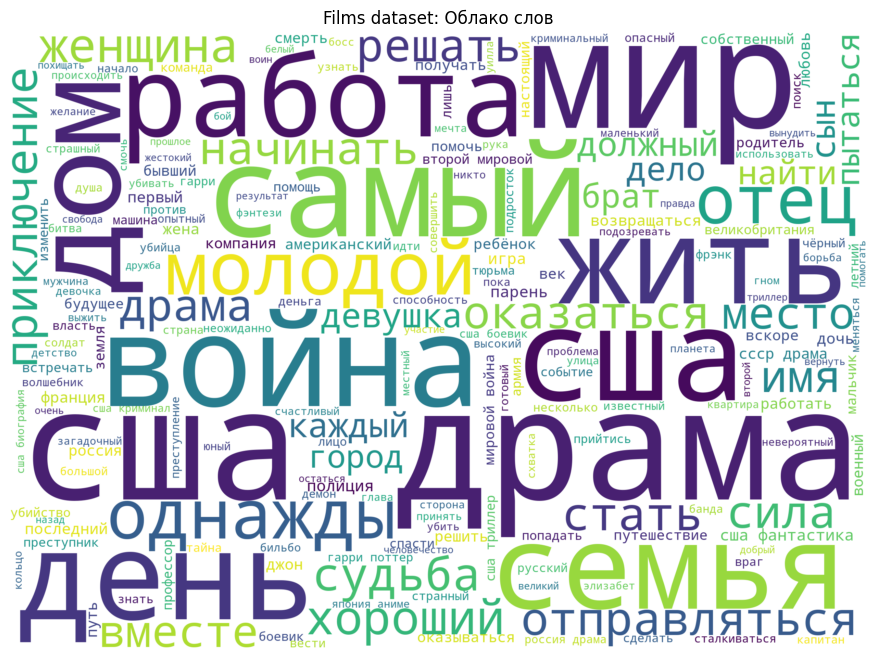

In [5]:
def get_wordcloud(text_series, title):
    corpus = " ".join(text_series.dropna().astype(str).tolist())
    wc = WordCloud(
        background_color="white",
        stopwords=STOPWORDS,
        width=2500,
        height=1800,
        max_words=200,
        random_state=42
    ).generate(corpus)
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

get_wordcloud(films_p["tokenize_text"], "Films dataset: Облако слов")


## Векторизация текстовых данных


In [6]:
count_vec = CountVectorizer(
    max_df=0.9,
    min_df=1,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer="word"
)
count_matrix = count_vec.fit_transform(films_p["tokenize_text"])

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=1,
    max_features=5000,
    ngram_range=(1, 3),
    analyzer="word"
)
tfidf_matrix = tfidf_vectorizer.fit_transform(films_p["tokenize_text"])

print("Count matrix shape:", count_matrix.shape)
print("TF-IDF matrix shape:", tfidf_matrix.shape)


Count matrix shape: (254, 5000)
TF-IDF matrix shape: (254, 5000)


## Тематическое моделирование: LDA (sklearn)


In [7]:
def print_topics_sklearn(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Тема {topic_idx + 1}: {' '.join(top_words)}")
        print()

def run_lda(count_matrix, feature_names, n_topics=5, title=""):
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=100
    )
    lda.fit(count_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    print_topics_sklearn(lda, feature_names, n_top_words=10)
    return lda

films_lda = run_lda(count_matrix, count_vec.get_feature_names_out(), 5, "Films dataset — LDA (sklearn)")


Films dataset — LDA (sklearn)
Тема 1: сша драма сша драма игра ссср война дом работа жена день

Тема 2: сша драма мир сша драма день ссср самый судьба найти дом

Тема 3: сша драма война жить вместе сша драма гарри стать приключение дело

Тема 4: сша русский земля демон ссср драма россия должный боевик путешествие

Тема 5: сша мир боевик холмс шерлок шерлок холмс решать драма преступник хороший



## LDA (Gensim) + когерентность


In [8]:
def run_gensim_lda(df: pd.DataFrame, n_topics=5, no_above=0.9, no_below=1, passes=10, random_state=42):
    token_lists = [word_tokenize(text) for text in df["text_lemm"]]
    dictionary = gensim.corpora.Dictionary(token_lists)
    dictionary.filter_extremes(no_above=no_above, no_below=no_below)
    dictionary.compactify()
    corpus = [dictionary.doc2bow(text) for text in token_lists]
    lda_model = gensim.models.LdaMulticore(
        corpus=corpus,
        num_topics=n_topics,
        id2word=dictionary,
        passes=passes,
        random_state=random_state
    )
    return dictionary, corpus, lda_model, token_lists

films_dict, films_corpus, films_gensim_lda, films_tokens = run_gensim_lda(films_p, n_topics=5)

print("Films Gensim LDA topics:")
for topic in films_gensim_lda.print_topics():
    print(topic)


Films Gensim LDA topics:
(0, '0.007*"сша" + 0.006*"драма" + 0.004*"ссср" + 0.004*"самый" + 0.004*"мир" + 0.003*"холмс" + 0.003*"шерлок" + 0.003*"оказаться" + 0.003*"происходить" + 0.003*"криминал"')
(1, '0.009*"сша" + 0.006*"драма" + 0.003*"полиция" + 0.003*"стать" + 0.003*"однажды" + 0.003*"каждый" + 0.003*"ссср" + 0.003*"отец" + 0.003*"день" + 0.003*"демон"')
(2, '0.010*"сша" + 0.005*"драма" + 0.004*"молодой" + 0.004*"день" + 0.004*"отправляться" + 0.003*"война" + 0.003*"хороший" + 0.003*"пытаться" + 0.003*"мир" + 0.002*"дом"')
(3, '0.010*"сша" + 0.007*"драма" + 0.006*"гарри" + 0.004*"война" + 0.004*"мир" + 0.003*"ссср" + 0.003*"семья" + 0.003*"жить" + 0.003*"поттер" + 0.003*"девушка"')
(4, '0.009*"сша" + 0.005*"драма" + 0.004*"мир" + 0.004*"война" + 0.003*"день" + 0.003*"кольцо" + 0.003*"работа" + 0.003*"игра" + 0.003*"жена" + 0.003*"судьба"')


In [9]:
films_coherence = CoherenceModel(
    model=films_gensim_lda,
    texts=films_tokens,
    dictionary=films_dict,
    coherence="c_v"
).get_coherence()

print("Films coherence (c_v):", films_coherence)


Films coherence (c_v): 0.3057249218836228


## NMF (Non-negative Matrix Factorization)


In [10]:
def run_nmf(tfidf_matrix, feature_names, n_topics=5, n_top_words=10, title=""):
    nmf_model = NMF(n_components=n_topics, random_state=0, init="nndsvda", max_iter=400)
    nmf_model.fit(tfidf_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    for i, topic in enumerate(nmf_model.components_):
        words = [feature_names[j] for j in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Тема {i + 1}: {', '.join(words)}")
    return nmf_model

films_nmf = run_nmf(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), 5, 10, "Films dataset — NMF")


Films dataset — NMF
Тема 1: драма, сша, сша драма, стать, семья, дом, мир, брат, жить, отец
Тема 2: гарри, гарри поттер, поттер, хогвартс, великобритания фэнтези, школа, великобритания, фэнтези, волшебник, школа чародейство волшебство
Тема 3: мировой война, второй мировой война, второй мировой, мировой, война, второй, биография, сша биография, американский, оппенгеймер
Тема 4: шерлок холмс, шерлок, холмс, доктор ватсон, ватсон, доктор, холмс доктор ватсон, холмс доктор, шерлок холмс доктор, схватка
Тема 5: фантастика, сша фантастика, будущее, терминатор, человечество, машина, марти, сша, помощь, мститель


## Топ фильмов по темам (NMF)


In [13]:
def top_docs_for_topics(model, tfidf_matrix, df, n_topics=5, top_docs=3, title_col="name"):
    transformed = model.transform(tfidf_matrix)
    for topic_idx in range(min(n_topics, transformed.shape[1])):
        topic_scores = transformed[:, topic_idx]
        top_docs_idx = np.argsort(topic_scores)[-top_docs:][::-1]
        print(f"Тема {topic_idx + 1}")
        for rank, doc_idx in enumerate(top_docs_idx, 1):
            row = df.iloc[doc_idx]
            print(f"  {rank}. {row[title_col]} — уверенность: {topic_scores[doc_idx]:.3f}")
        print()

print("Films dataset — топ фильмов по темам (NMF):")
top_docs_for_topics(films_nmf, tfidf_matrix, films_p, n_topics=5, top_docs=3)


Films dataset — топ фильмов по темам (NMF):
Тема 1
  1. Марли и я — уверенность: 0.150
  2. Шоу Трумана — уверенность: 0.149
  3. Невидимая сторона — уверенность: 0.146

Тема 2
  1. Гарри Поттер и Тайная комната — уверенность: 0.569
  2. Гарри Поттер и Кубок огня — уверенность: 0.562
  3. Гарри Поттер и узник Азкабана — уверенность: 0.531

Тема 3
  1. Игра в имитацию — уверенность: 0.451
  2. По соображениям совести — уверенность: 0.450
  3. Оппенгеймер — уверенность: 0.413

Тема 4
  1. Приключения Шерлока Холмса и доктора Ватсона: Охота на тигра — уверенность: 0.698
  2. Приключения Шерлока Холмса и доктора Ватсона: Король шантажа — уверенность: 0.692
  3. Шерлок Холмс и доктор Ватсон: Смертельная схватка — уверенность: 0.673

Тема 5
  1. Терминатор — уверенность: 0.500
  2. Назад в будущее 2 — уверенность: 0.497
  3. Назад в будущее — уверенность: 0.486



## LSA (Latent Semantic Analysis)


In [12]:
def run_lsa(tfidf_matrix, feature_names, n_topics=5, n_top_words=10, title=""):
    lsa_model = TruncatedSVD(n_components=n_topics, random_state=0)
    lsa_model.fit(tfidf_matrix)
    print("=" * 70)
    print(title)
    print("=" * 70)
    for i, topic in enumerate(lsa_model.components_):
        words = [feature_names[j] for j in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Тема {i + 1}: {', '.join(words)}")
    return lsa_model

films_lsa = run_lsa(tfidf_matrix, tfidf_vectorizer.get_feature_names_out(), 5, 10, "Films dataset — LSA")


Films dataset — LSA
Тема 1: сша, драма, война, сша драма, мир, самый, ссср, семья, стать, дом
Тема 2: гарри, гарри поттер, поттер, хогвартс, великобритания фэнтези, фэнтези, школа, волшебник, курс школа чародейство, великобритания фэнтези гарри
Тема 3: второй мировой война, второй мировой, мировой война, мировой, второй, война, гарри, биография, сша биография, гарри поттер
Тема 4: шерлок, холмс, шерлок холмс, доктор ватсон, ватсон, доктор, холмс доктор ватсон, холмс доктор, шерлок холмс доктор, схватка
Тема 5: сша фантастика, фантастика, терминатор, будущее, человечество, машина, марти, сша, мститель, мир
